## Module_3: Fibrosis

## Tomas Daniel and Reagan Oswald 

## How Fibrosis Changes with Lung Depth: A Quantitative and Predictive Analysis



## Project Goal:
Our team has developed an image analysis pipeline that predicts the extent of fibrosis at different biopsy depths.​

This project seeks to answer two questions: ​

1) How does the extent of fibrosis vary throughout the depth of a fibrotic
lung? ​

2) And, using interpolation, can we predict the amount of fibrosis at a
specific depth into the lung? 

## Disease Background: 

Lung Fibrosis is something that is often overlooked. It affects around 3 million people around the world, with an incidence of anywhere around 3-9 cases per 100,000 people. This number is expected to rise with improved diaganostics, but also with an alarming increase of vaping in teens. It is more common in men that in is women though, with a perceived ratio of 2 men to every 1 women. While genetic mutations and familial history are big causes, some other notable ones include age and smoking, with smoking being the biggest risk factor. Inhaling dust chronically, like through one's job, is another casue of lung fibrosis. 

Symptoms start with a dry cough, fatigue, and shortness of breath (dyspnea) with exertion. The dyspnea progresses to where the shortness of breath is felt even when resting. Extreme cases can result in pulmonary hypertension or even right heart failure. Treatment is generally ineffective at stopping anything either, with two FDA-approved drugs (Pirfenidone and Nintedanib) only serving to slow the disease's progression. The only real treatment is a full lung transplant, but the waiting list for these transplants spans years. Other things like pulmonary rehabilitation serve to improve the quality of life, but again can't fix the issue fully. 

Biologically, lung fibrosis is the permanent scarring of the lung parenchyma. This fibrosis destroys the alveolar and triggers aberrant wound healing, which in turn decreases the total lung capacity and forced vital capacity. Aberrant wound healing means that excess collagen is pumped into the extracellular matrix (ECM) of the lung tissues, resulting in the stiffer tissue that is fibrosis. 


## Data-Set: 
This dataset comprises 78 black-and-white JPEG images of fibrotic mouse lung tissue, collected at sequential depths ranging from 0 µm to 10,000 µm. The lungs were harvested from mice treated with Bleomycin (Blenoxane), a chemotherapeutic agent known to induce pulmonary fibrosis, thereby serving as a model for idiopathic pulmonary fibrosis (IPF). After fixation with paraformaldehyde and embedding in gel or wax, the tissue was sectioned in the transverse plane using a cryotome or microtome. Each slice was mounted on a glass slide and immunostained with a fluorescent-labeled antibody targeting desmin, a marker for myofibroblasts—cells responsible for scar formation. The fluorescent signal was captured via microscopy and converted into grayscale images, where white regions denote fibrotic lesions and black regions represent healthy lung tissue.

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 


## Data Analyis: 




### Import Packages

In [5]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

### Open Selected Images
Below are the 6 images we chose to analyze from the complete set of phots we were given

In [6]:
selected_images = [
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010017.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010040.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010065.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010160.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010174.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010083.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010112.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010136.jpg",
    r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg"
]

### Gather Data

The code below counts the pixels in each image for the specified depth

In [ ]:
# Depths (microns)
depths = [45, 200, 380, 3900, 7200, 3100, 2400, 5500, 9200, 7500]

white_counts = []
black_counts = []
white_percents = []

print(colored("Counts of pixels by color in each image", "yellow"))

for filename, depth in zip(selected_images, depths):

    # Load image in grayscale (force 8-bit)
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Count white and black pixels
    white = np.sum(binary == 255)
    black = np.sum(binary == 0)
    total = white + black

    # Percent white
    white_percent = (white / total)*100

    # Store values
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)

    # Print results
    print(colored(f"{filename}:", "red"))
    print(colored(f"White pixels: {white}", "white"))
    print(colored(f"Black pixels: {black}", "blue"))
    print(f"{white_percent:.2f}% White | Depth: {depth} microns\n")
    


# Save results to CSV
Pixels = pd.DataFrame({
    "Filename": selected_images,
    "Depth (microns)": depths,
    "White Percent": white_percents})

Pixels.to_csv("Percent_White_Pixels.csv", index=False)

print("CSV file 'Percent_White_Pixels.csv' created.")
print("Unique values:", np.unique(binary))


Counts of pixels by color in each image
C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010017.jpg:
White pixels: 27561
Black pixels: 4166743
0.66% White | Depth: 45 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010030.jpg:
White pixels: 37799
Black pixels: 4156505
0.90% White | Depth: 200 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010040.jpg:
White pixels: 41943
Black pixels: 4152361
1.00% White | Depth: 380 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010065.jpg:
White pixels: 83951
Black pixels: 4110353
2.00% White | Depth: 3900 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010160.jpg:
White pixels: 118409
Black pixels: 4075895
2.82% White | Depth: 7200 microns

C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010174.j

### Data Plot:

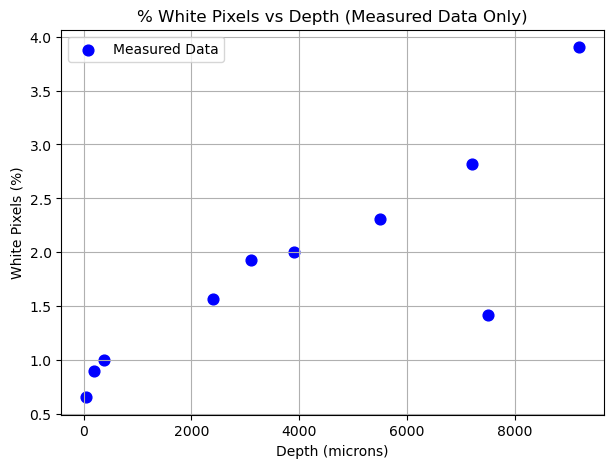

In [21]:
# Load CSV
df = pd.read_csv("Percent_White_Pixels.csv")

# Extract columns
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()

# PLOT: RAW MEASURED DATA ONLY
plt.figure(figsize=(7,5))

plt.scatter(x, y, color='blue', s=60, label='Measured Data')

plt.title("% White Pixels vs Depth (Measured Data Only)")
plt.xlabel("Depth (microns)")
plt.ylabel("White Pixels (%)")
plt.grid(True)
plt.legend()
plt.show()

### Linear Interpolation:



Linear interpolation at depth 2000.0: 1.453% white



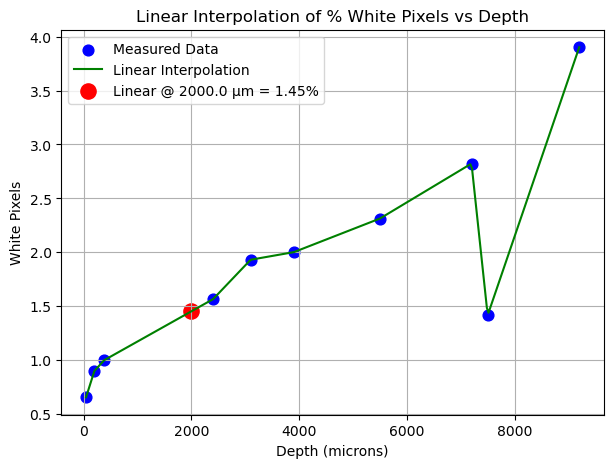

In [33]:
# LOAD YOUR DATA
df = pd.read_csv("Percent_White_Pixels.csv")
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()


# USER INPUT
interp_depth = float(input("Enter the depth at which you want to interpolate (microns): "))


# LINEAR INTERPOLATION
linear_f = interp1d(x, y, kind='linear')
linear_value = float(linear_f(interp_depth))
print(f"\nLinear interpolation at depth {interp_depth}: {linear_value:.3f}% white\n")


# PLOT: LINEAR INTERPOLATION
plt.figure(figsize=(7,5))

# Plot original data
plt.scatter(x, y, color='blue', s=60, label='Measured Data')

# Plot linear interpolation line
x_line = np.linspace(min(x), max(x), 300)
y_line = linear_f(x_line)
plt.plot(x_line, y_line, color='green', label='Linear Interpolation')

# Plot interpolated point
plt.scatter(interp_depth, linear_value, color='red', s=120, label=f'Linear @ {interp_depth} µm = {linear_value:.2f}%')
plt.title("Linear Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Quadratic Interpolation





Quadratic interpolation at depth 2000.0: 1.395% white



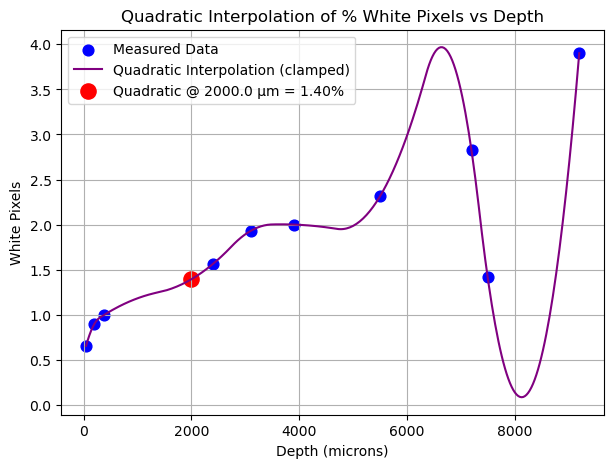

In [32]:
# LOAD YOUR DATA
df = pd.read_csv("Percent_White_Pixels.csv")
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()

interp_depth = float(input("Enter the depth at which you want to interpolate (microns): "))

# QUADRATIC INTERPOLATION (SciPy spline)
quad_f = interp1d(x, y, kind='quadratic')

quad_value = float(quad_f(interp_depth))

print(f"\nQuadratic interpolation at depth {interp_depth}: {quad_value:.3f}% white\n")

plt.figure(figsize=(7,5))

plt.scatter(x, y, color='blue', s=60, label='Measured Data')

x_line = np.linspace(min(x), max(x), 300)
y_line = quad_f(x_line)
            # clamp curve

plt.plot(x_line, y_line, color='purple', label='Quadratic Interpolation (clamped)')

plt.scatter(interp_depth, quad_value, color='red', s=120, label=f'Quadratic @ {interp_depth} µm = {quad_value:.2f}%')

plt.title("Quadratic Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("White Pixels")
plt.grid(True)
plt.legend()
plt.show()

### Cubic Interpolation


Cubic (3rd-degree) interpolation at depth 2000.0: 1.398% white



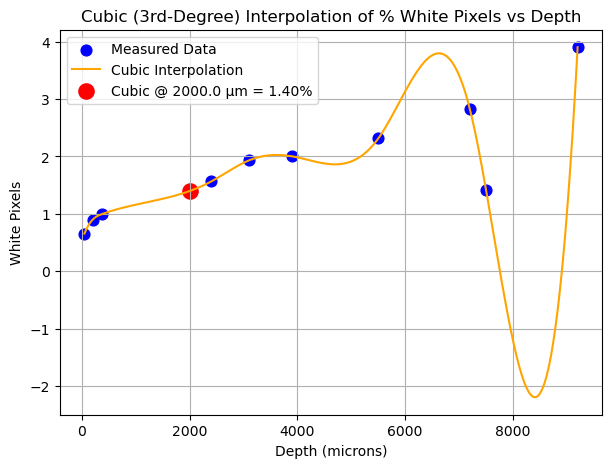

In [31]:
# LOAD YOUR DATA
df = pd.read_csv("Percent_White_Pixels.csv")
x = df["Depth (microns)"].tolist()
y = df["White Percent"].tolist()


# USER INPUT
interp_depth = float(input("Enter the depth at which you want to interpolate (microns): "))


# CUBIC (3rd-degree) INTERPOLATION
cubic_f = interp1d(x, y, kind='cubic')
cubic_value = float(cubic_f(interp_depth))
print(f"\nCubic (3rd-degree) interpolation at depth {interp_depth}: {cubic_value:.3f}% white\n")


# PLOT: CUBIC INTERPOLATION
plt.figure(figsize=(7,5))

# Plot original measured data
plt.scatter(x, y, color='blue', s=60, label='Measured Data')

# Plot cubic interpolation curve
x_line = np.linspace(min(x), max(x), 300)
y_line = cubic_f(x_line)  
plt.plot(x_line, y_line, color='orange', label='Cubic Interpolation')

# Plot interpolated point
plt.scatter(interp_depth, cubic_value, color='red', s=120, label=f'Cubic @ {interp_depth} µm = {cubic_value:.2f}%')
plt.title("Cubic (3rd-Degree) Interpolation of % White Pixels vs Depth")
plt.xlabel("Depth (microns)")
plt.ylabel("White Pixels")
plt.grid(True)
plt.legend()
plt.show()

## Verify and validate your analysis: 
Verification:

Do these results make sense?
    
    To test our code and interpolation methods we used the depth 2000 micrometers. For this depth our three interpolation graphs got three different white percentage values, but graphs 2 and 3 (quadratic and cubic) were a lot closer toegther. This makes sense because as you increase the function degree, the accuracy of the estimation should increase, so the distance between each estimation would be smaller. Although the linear interpolation was closest to the actual value, the seperation between values was still expected. 


Validation:
    
    We picked 10 images spaced out and chose an interpolation of 2000. One of the images actually has this value so below are the calculations of this. The linear interpolation was closest to the actual value which was found to be 1.5%. The linear estimation was 1.45%. 

    Something we first noticed about our scatterplot is that the points seem to have a general correlation btthere are still some outliers. With some more research we learned that Bleomycin‑induced lung fibrosis is inherently patchy and spatially heterogeneous (Franzén et al., 2024). Each region of the lung has extremly different mechanical and biochemical enviornments. Fibrosis develops more strngly in some microenviornments then others so it would make sense that across differen enviornemnts, theres' verying amounts of lesions, resulting in the graph leveling out at some points and incrasing at others.

    Its also an important part of valiation to make sure the project goals were answered as a whole.In the begining we wantedto answer two questions.
    1) How does the extent of fibrosis vary throughout the depth of a fibrotic lung? ​
    As decribed above, we determined that it doesn't depend soley on depth, and instead is presented as slightly spread out.

    2) And, using interpolation, can we predict the amount of fibrosis at a specific depth into the lung? 
    We can use interpolation to predict the amount of fibrosis, it's just important to do it with multiple degrees for interpolation grahs to decipher the most accurate answer possible.

In [30]:
#Percentage of white pixel for testing Interpolation

# Path to image
filename = r"C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010146.jpg"

# Load image in grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Convert to binary: everything above 127 becomes white (255)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Count pixels
white = np.sum(binary == 255)
black = np.sum(binary == 0)
total = white + black

white_percent = (white / total) * 100

# Print results
print("Image:", filename)
print("White pixels:", white)
print("Black pixels:", black)
print(f"White percent: {white_percent:.2f}%")

Image: C:\Users\Reaga\OneDrive\Desktop\BME_2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010146.jpg
White pixels: 62913
Black pixels: 4131391
White percent: 1.50%


## Conclusions and Ethical Implications: 

Based on our pixel analysis of six lung images taken at depths ranging from 45-9200 microns, the percentage of white pixels (fibrotic tissue) fluctuated across depths rather than following a simple linear trend, with values ranging from approximately 1-4%. This implies that fibrosis is not perfectly uniformly distributed throughout the lung tissue, which ties into how we understand the disease's progression. Utilizing linear, quadratic, and cubic interpolations, we were also able to predict fibrosis levels at depths we don't have images for. For example, at a depth of 2000 micrometers we estimated around  fibrosis, depending on the degree of interpolation used. Because these estimates are so close to one another, it increases the credibility of our analysis. 


The ethical implications of our work is also quite clear. If image-based quantification and interpolation can reliably estimate fibrosis levels in lung tissues, this approach could reduce the need for invasive biopsies and help clinicians monitor disease progression more accurately and less painfully. However, since patient safety is always the top priority, it's crucial that such tools are approved and validated before clinical use, as overconfidence in predictive modeling could lead to a misdiagnosis, delayed treatment, and potentially even death. Additionally, because lung fibrosis disproportionately affects older populations and those with occupational exposures, equitable access to advanced imaging diagnostics must be considered so that these tools benefit all patients, not just those with access to well-resourced healthcare systems.


## Limitations and Future Work: 
There are several limitations in this project, with one glaring one. The big one is that our analysis was based on only six images from a single lung sample, which significantly limits our ability to generalize the data and draw conclusions from it. A more better analysis would use images from multiple patients, with varying degrees of fibrosis. Expanding the dataset is something we could do in the future, potentially even if we had more time. Another issue is there is a gap in the depth sequences we used. Rather than looking at images with a set increment of depth between them, we used ones with varying jumps between their depths. This could paint an odd picture as we piece the data together, and our interpolations might have had to do more work to adjust for this inconsistency. Future work could have use look through the images and find a set with a uniform increment to allieviate any of the issues that stem from it. Finally, the images in our dataset relied on pixels (white vs. black), which could be an oversimplification. Fibrosis and fibrotic tissue exists on a spectrum of intensity and structure, and a black and white image may not fully document the severity of a given case. While it may prove difficult, we could explore other imaging techniques to more precisely identify and quantify fibrotic regions to account for their varying intensities. Ultimately, this could look like extending this analysis into three dimensions, with depth slices combining to create a volumetric map of fibrosis distribution. Doing so could help us get a better understanding of the fibrosis throughout the lung.

## References:
"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 
Sontake et al., 2024 — “Mapping spatially resolved transcriptomes in human and mouse pulmonary fibrosis.”

Franzén, L., Lindvall, M. O., Hühn, M., Ptasinski, V., Setyo, L., Keith, B. P., Collin, A., Oag, S., Volckaert, T., Borde, A., Lundeberg, J., Lindgren, J., Belfield, G., Jackson, S., Ollerstam, A., Stamou, M., Ståhl, P. L., & Hornberg, J. J. (2024). Mapping spatially resolved transcriptomes in human and mouse pulmonary fibrosis. Nature Genetics, 56(8), 1725–1736. https://doi.org/10.1038/s41588-024-01819-2